# COSETTE & MARIUS: a beyond-accuracy study of generative recommendation

This notebook is the consolidated extension story for our reproduction of *Closing the Performance Gap in Generative Recommenders with Collaborative Tokenization and Efficient Modeling* (Lepage, Mary, Picard; arXiv:2508.14910). It is organized around four research questions, following the FairDiverse (SIGIR'25) pre/in/post-processing taxonomy for the mitigation half.

**RQ1.** Is COSETTE/MARIUS reproducible against SASRec++, and how does the verdict change with catalog scale?

**RQ2.** How do the discriminative (SASRec++) and generative (MARIUS) paradigms compare on diversity and popularity bias (coverage, Gini, entropy, ILD)?

**RQ3.** What in the generative pipeline causes the popularity bias - the semantic-ID distribution, the training data, the model, or the beam search?

**RQ4.** How well can the bias be mitigated at each pipeline stage (training loss, beam, re-ranking, cross-paradigm distillation), and at what accuracy cost?

Every figure is computed from committed artifacts in `reports/`. Model accuracy comes from the authors' unmodified evaluation code; beyond-accuracy metrics are recomputed from the models' own ranked outputs and match the official Recall@10 to the decimal. Datasets: Amazon-2014 Beauty (12k items) and Sports (18k), and Amazon-2023 Arts_Crafts_and_Sewing (90k) for the large-scale prong.

All numbers here are cross-checked in `EXTENSION_RESULTS.md`.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

REPO = Path.cwd()
while not (REPO / 'scripts' / 'extensions' / 'extension_figures.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from scripts.extensions import extension_figures as ef
import matplotlib.pyplot as plt
from IPython.display import display

# Figures are defined once in extension_figures.py and reused here. The same
# module, run as a script, writes every figure to reports/figures/ as PNG+SVG
# for direct inclusion in the paper:  python scripts/extensions/extension_figures.py
def show(fig):
    """Render a figure exactly once (display, then close so the inline backend
    does not also auto-flush it)."""
    display(fig); plt.close(fig)

pd.set_option('display.float_format', lambda v: f'{v:.4f}')

## RQ1. Reproducibility, and the small-to-large flip

The paper claims MARIUS+COSETTE is competitive with the tuned SASRec++ baseline at small scale and beats it at large scale. We reproduce both ends.

On the small 2014 datasets the claim does **not** reproduce: a paper-faithful SASRec++ (per-dataset sizing, no L2 normalization) beats MARIUS on Beauty (9.06 vs 8.17 Recall@10) and Sports (5.15 vs 4.87). But on the large 2023 Arts dataset (90k items) the claim **does** reproduce: MARIUS 5.01 vs SASRec++ 4.86, a separation that holds across all five seeds (exact permutation p=0.008). The generative paradigm's advantage is scale-dependent.

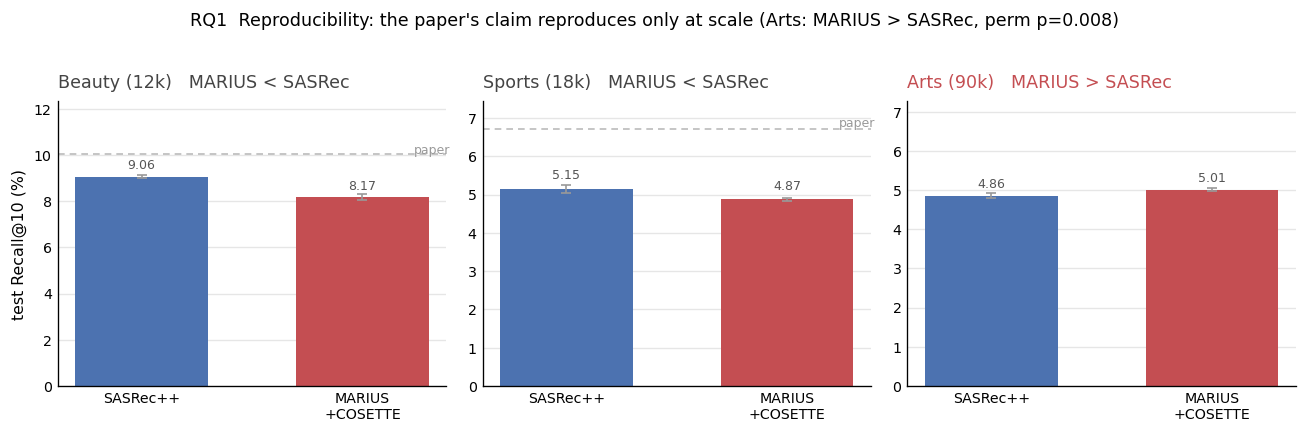

In [2]:
show(ef.fig_rq1_reproduction())

## RQ2. Diversity and popularity bias

From each model's ranked top-10 we measure catalog coverage (fraction of items ever recommended), the Gini coefficient of exposure, intra-list diversity (ILD, the average pairwise content distance within a list), and APLT (the average share of long-tail items per list).

The result is more specific than 'MARIUS is less diverse'. MARIUS's individual lists are about as diverse as SASRec's (ILD tied) and lean **more** to the long tail (higher APLT, lower ARP). Yet in **aggregate** it reaches far fewer distinct items (Arts coverage 0.40 vs 0.59; Sports 0.39 vs 0.74) at equal-or-higher Gini. This is the aggregate-vs-individual diversity distinction (Adomavicius & Kwon 2012): MARIUS serves a reasonably varied but largely overlapping popular slice of the catalog across users. The collapse is worst on the sparsest data and persists at 90k scale.

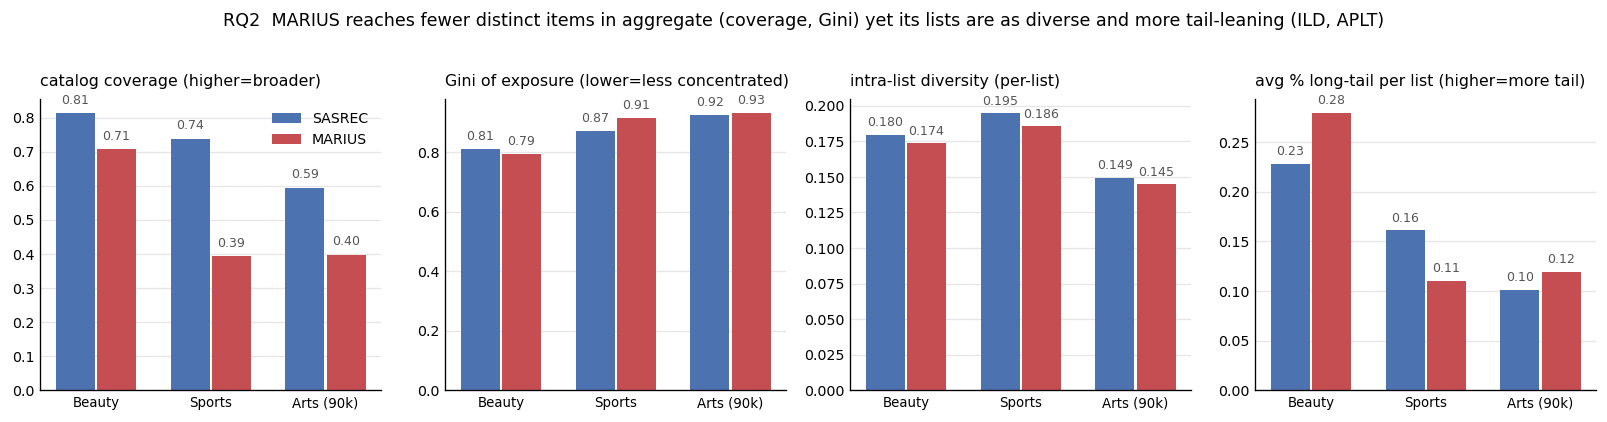

In [3]:
show(ef.fig_rq2_beyond_accuracy())

In [4]:
# The Arts (90k) beyond-accuracy table, 5-seed mean (k=10).
ab = ef.arts_beyond(); reach = ef.arts_reach()
cols = ['coverage', 'gini', 'entropy_norm', 'ild', 'aplt', 'arp', 'recall', 'tail_recall']
tbl = ab[ab.k == 10].set_index('model')[cols].copy()
tbl['chao1_ceiling'] = [reach.loc[(m, 10), 'chao1_coverage_mean'] for m in tbl.index]
tbl.round(4)

,coverage,gini,entropy_norm,ild,aplt,arp,recall,tail_recall,chao1_ceiling
model,,,,,,,,,
marius,0.3969,0.9302,0.7681,0.1447,0.1192,171.4874,0.0501,0.0082,0.4672
sasrec,0.5932,0.9236,0.7492,0.1494,0.1009,207.7500,0.0486,0.0090,0.6932


## RQ3. Where does the bias come from? The exact-oracle diagnosis

A generative recommender can only surface an item whose semantic-ID code its beam writes, so the collapse could live in the codebook, the data, the model's learned ranking, or the beam search. We settle it with an **exact full-catalog oracle**: for ~1000 test users we teacher-force MARIUS to score *every* catalog item's code tuple, giving the model's exact ranking independent of the beam.

The verdict is **model-bound**. Exact scoring recovers essentially the same Recall@10 as the beam (so the beam is near-optimal over the model - not the culprit), while the true held-out items sit at a median exact rank of ~1956 out of 90k on Arts (and ~1000/18k on Sports). The model's learned ranking buries the tail. This replicates the small-scale finding at 90k and refutes accounts that blame premature beam pruning (e.g. SimGR). The codebook audit (256/256 codes used, near-uniform) independently rules out the tokenizer.

The distilled checkpoint (see RQ4) is shown here too: distillation spreads exposure but pushes the true targets *deeper* (median 1000 to 1405), so the verdict stays model-bound even after the strongest intervention.

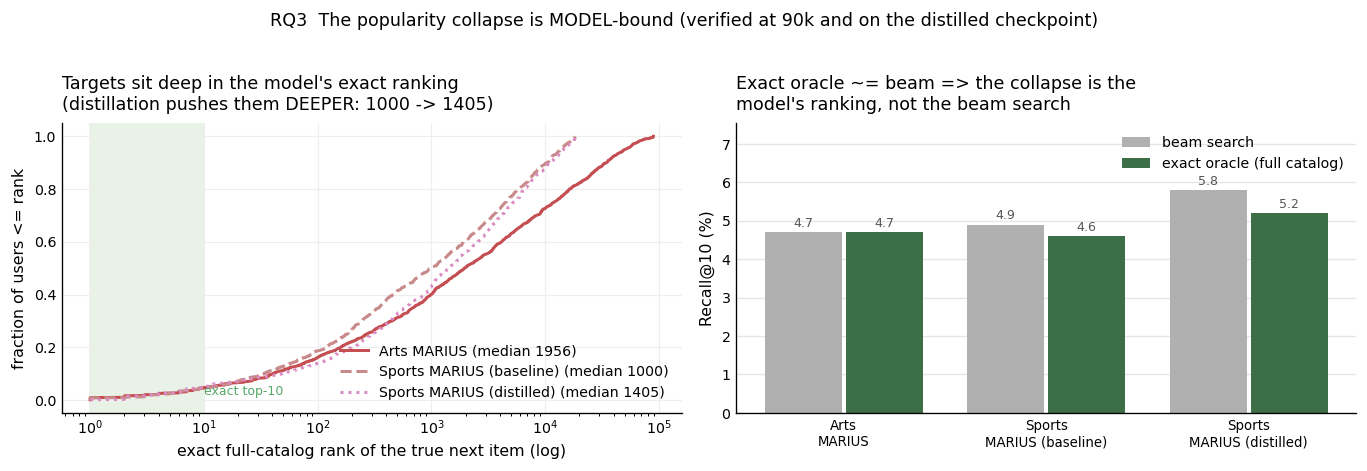

In [5]:
show(ef.fig_rq3_oracle())

In [6]:
# Oracle verdicts (filtered where available; distilled is unfiltered-only).
import json
def verdict(p):
    d = json.loads(Path(p).read_text()); k10 = {r['k']: r for r in d['per_k']}[10]
    return {'verdict': d['verdict'], 'recall_exact@10': k10['recall_exact'],
            'recall_beam@10': k10['recall_beam'],
            'median_target_rank': d['target_exact_rank_median_all'],
            'n_catalog': int(np.load(str(p).replace('.json', '.npz'))['n_catalog'])}
rows = {
    'Arts MARIUS': ef.ARTS_DIR / 'seed42' / 'exact_catalog' / f'exact_catalog_{ef.ARTS}_seed42_filtered.json',
    'Sports baseline': ef.EXT / 'exact_catalog' / 'exact_catalog_Sports_and_Outdoors_seed42_filtered.json',
    'Sports distilled': ef.EXT / 'exact_catalog_distill' / 'exact_catalog_Sports_and_Outdoors_seed42.json',
}
pd.DataFrame({k: verdict(v) for k, v in rows.items()}).T

,verdict,recall_exact@10,recall_beam@10,median_target_rank,n_catalog
Arts MARIUS,MODEL-bound,0.0470,0.0470,1956.0000,89958
Sports baseline,MODEL-bound,0.0490,0.0490,996.0000,18357
Sports distilled,MODEL-bound,0.0520,0.0580,1405.0000,18357


## RQ4. Mitigation across pipeline stages, and the trade-off

We test one mitigation per FairDiverse stage and compare their accuracy-vs-bias trade-offs:

- **in-processing** (training loss): logit-adjusted cross-entropy (MARIUSLogitAdj), a per-token popularity correction, swept over tau on Beauty and Sports;
- **beam stage**: MBR re-ranking of the depth-100 candidates, swept over tau;
- **post-processing**: PMI / logit-adjusted decode-time re-rank (priors cond2 / pair / item), swept over alpha, on Arts;
- **cross-paradigm**: KL distillation of a frozen SASRec++ teacher into MARIUS.

The unified result: **every lever is a bounded dial** that buys catalog coverage with recall, and **none moves the model-bound ceiling**. Panel A shows the clean Arts Pareto for the re-rankers; panel B normalizes every arm to its own baseline so all four stages share one axis. Distillation is the extreme - it nearly matches the teacher's spread (coverage 0.39 to 0.87, +123%) but costs 22% of Recall@10, and the RQ3 oracle shows it does this by smearing mass, not by ranking the correct items higher (their exact rank gets *worse*). Aggregate coverage can be inflated without improving the model's ability to serve the tail; only the oracle distinguishes genuine reach from cosmetic spreading.

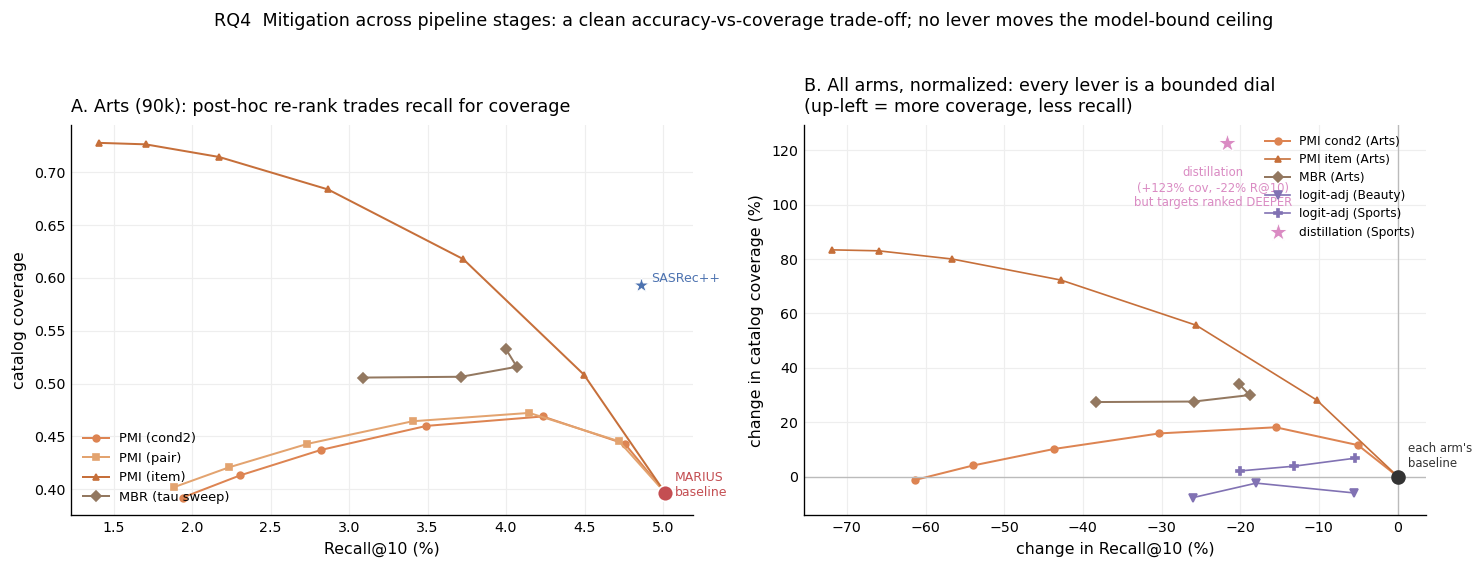

In [7]:
show(ef.fig_rq4_pareto())

In [8]:
# Representative trade-off points (% change vs each arm's own baseline, k=10).
out = []
# post: PMI cond2 @ alpha 0.5 (Arts)
p = ef.arts_pmi('cond2'); b = p.loc[0.0]
out.append(['post: PMI cond2 a=0.5 (Arts)', 100*(p.loc[0.5].recall-b.recall)/b.recall,
            100*(p.loc[0.5].coverage-b.coverage)/b.coverage])
# beam: MBR tau1.0 (Arts)
bm, dm = ef.arts_mbr()
out.append(['beam: MBR tau=1.0 (Arts)', 100*(dm.loc[1.0].recall-bm['recall'])/bm['recall'],
            100*(dm.loc[1.0].coverage-bm['coverage'])/bm['coverage']])
# in: logit-adj tau1.5 (Sports)
lb, ld = ef.logitadj('sports', 'Sports_and_Outdoors')
out.append(['in: logit-adj tau=1.5 (Sports)', 100*(ld.loc[1.5].recall_mean-lb.recall_mean)/lb.recall_mean,
            100*(ld.loc[1.5].coverage_mean-lb.coverage_mean)/lb.coverage_mean])
# distillation (Sports)
db, dd = ef.distill()
out.append(['cross-paradigm: distillation (Sports)', 100*(dd.recall_mean-db.recall_mean)/db.recall_mean,
            100*(dd.coverage_mean-db.coverage_mean)/db.coverage_mean])
pd.DataFrame(out, columns=['arm (stage)', 'dRecall@10 %', 'dCoverage %']).round(1)

,arm (stage),dRecall@10 %,dCoverage %
0,post: PMI cond2 a=0.5 (Arts),-15.5000,18.2000
1,beam: MBR tau=1.0 (Arts),-25.9000,27.6000
2,in: logit-adj tau=1.5 (Sports),-20.1000,2.1000
3,cross-paradigm: distillation (Sports),-21.7000,122.7000


## Synthesis

| Question | Finding |
|---|---|
| RQ1 Reproducible? | Yes, scale-dependent: MARIUS < SASRec++ on 2014 (Beauty 8.17 vs 9.06), MARIUS > SASRec++ on Arts-2023 (5.01 vs 4.86, p=0.008). |
| RQ2 Diversity / bias? | Aggregate collapse (Arts coverage 0.40 vs 0.59, Gini ~0.93) despite competitive per-list diversity (ILD tied, APLT higher). Worsens with sparsity; persists at 90k. |
| RQ3 Source? | The model's learned ranking. Exact oracle ~= beam (not search); true targets at median exact rank ~1956/90k; codebook audit clears the tokenizer. |
| RQ4 Mitigation? | Every stage (loss / beam / re-rank / distillation) is a bounded dial trading recall for coverage; none lifts the ceiling. Distillation spreads most (coverage +123%) but buries the true targets deeper. |

The through-line: in semantic-ID generative recommendation the popularity collapse is a property of the trained model's ranking, not of decoding or tokenization, and popularity-correction levers redistribute exposure without expanding genuine reach. Measuring aggregate coverage alone is misleading; the exact oracle is needed to tell real reach from cosmetic spreading.

Verified numbers and provenance: `EXTENSION_RESULTS.md`. Reproduction methodology: `REPLICATION_REPORT.md`, `FAITHFUL_RERUN.md`. The earlier diagnostic log is `EXTENSION_SUMMARY.md`. Figures are regenerated by `python scripts/extensions/extension_figures.py`.